<h1 style="color:rgba(37, 214, 191, 1);">IMPORTS</h1>

In [13]:
# Todos los imports necesitados en todo el notebook (No hay imports en otras celdas)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import random
import os
import joblib
import keras
from keras.losses import BinaryFocalCrossentropy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils import class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import TensorBoard
#from category_encoders import TargetEncoder
from scipy import sparse

<h1 style="color:rgba(187, 32, 187, 1);">Exploración Inicial y Análisis Descriptivo (EDA)</h2>

In [14]:
print("TensorFlow version:", tf.__version__)
print("GPUs visibles:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs visibles: []


### 1. Carga del data frame

In [ ]:
# Cargamos el dataset en nuestro dataframe df
df = pd.read_csv("data_TPFP.csv")

# Vamos a modificar este parametro a pandas para que nos muestre todas las columnas del dataframe
pd.set_option('display.max_columns', None)

# Mostramos el nuestro dataset
#df.head(10)
# CENSURADO POR PRIVACIDAD DE LA EMPRESA

In [16]:
df.shape

(139930, 18)

In [17]:
# Vamos a ver que tipo de datos tenemos en cada columna
df.dtypes

orig_client          object
orig_index           object
orig_rule_title      object
rule_description     object
severity             object
src_ip               object
dest_ip              object
dest_port            object
action               object
signature            object
Country              object
user                 object
hostname             object
sender               object
subject              object
recipient            object
url                  object
disposition_label    object
dtype: object

### 2. Modificación de los datos

In [18]:
df["disposition_label"].value_counts()

disposition_label
TP_No_Impact                 99619
TP_No_Impact_SOAR            22938
FP_SIEM                       8666
FP_Usual_Activity             3767
Tuning_Requested              2244
TP_Incident_Resolved_SOAR     2044
TP_Incident_Resolved           174
Duplicated_SOAR                168
FP_Usual_Activity_SOAR          74
FP_Vendor_Config                72
Duplicated                      48
Undetermined                    39
FP_SIEM_SOAR                    34
Tuning_Requested_SOAR           30
TP_Incident_Unresolved          13
Name: count, dtype: int64

In [19]:
def preprocess_for_mlp_new(
    csv_path,
    preprocessor_path="preprocessor.joblib",
    fit_new=False
):
    # --------------------------------------------------
    # 1. Carga del dataset
    # --------------------------------------------------
    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()

    # --------------------------------------------------
    # 2. Variable objetivo (TP / FP)
    # --------------------------------------------------
    if "disposition_label" in df.columns:
        df["disposition_label"] = (
            df["disposition_label"]
              .astype(str)
              .str.strip()
              .str.upper()
        )

        # Nos quedamos solo con TP y FP
        df = df[df["disposition_label"].str.startswith(("TP", "FP"))].copy()

        # TP → 1, FP → 0
        y = np.where(
            df["disposition_label"].str.startswith("TP"),
            1,
            0
        )
    else:
        y = None

    # --------------------------------------------------
    # 3. Limpieza de columnas
    # --------------------------------------------------
    if "dest_port" in df.columns:
        df["dest_port"] = (
            df["dest_port"]
              .astype(str)
              .str.replace(r"[\[\],]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip()
        )

    # --------------------------------------------------
    # 4. Definición de features
    # --------------------------------------------------
    categorical_features = [
        "orig_client",
        "severity",
        "action",
        "Country"
    ]

    text_features = [
        "orig_rule_title",
        "rule_description",
        "signature",
        "subject",
        "url",
        "sender",
        "recipient",
        "dest_port",
        "hostname",
        "user",
        "src_ip",
        "dest_ip",
    ]

    # Nos quedamos solo con las columnas que existen
    categorical_features = [c for c in categorical_features if c in df.columns]
    text_features = [c for c in text_features if c in df.columns]

    # Forzamos string y rellenamos NaNs
    for col in categorical_features + text_features:
        df[col] = df[col].astype(str).fillna("")

    # --------------------------------------------------
    # 5. Carga del preprocessor si ya existe
    # --------------------------------------------------
    if os.path.exists(preprocessor_path) and not fit_new:
        preprocessor = joblib.load(preprocessor_path)
        X = preprocessor.transform(df)
        return X, y, preprocessor, df

    # --------------------------------------------------
    # 6. Construcción del ColumnTransformer
    # --------------------------------------------------
    transformers = []

    # Categóricas → OneHot
    if categorical_features:
        transformers.append(
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ),
                categorical_features
            )
        )

    # Texto → TF-IDF (una columna = un vectorizador)
    for col in text_features:
        transformers.append(
            (
                f"tfidf_{col}",
                TfidfVectorizer(
                    max_features=500,
                    ngram_range=(1, 2),
                    stop_words="english"
                ),
                col
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.3
    )

    # --------------------------------------------------
    # 7. Fit + Transform
    # --------------------------------------------------
    X = preprocessor.fit_transform(df)

    joblib.dump(preprocessor, preprocessor_path)
    print(f"Preprocessor guardado en: {preprocessor_path}")

    return X, y, preprocessor, df

In [20]:
X, y, preproc, df_proc = preprocess_for_mlp_new(
    "data_TPFP.csv",
    preprocessor_path="preprocessor.joblib",
    fit_new=True
)

Preprocessor guardado en: preprocessor.joblib


In [21]:
pd.Series(y).value_counts()

1    124788
0     12613
Name: count, dtype: int64

In [22]:
print("Shape X:", X.shape)

if y is not None:
    print("Shape y:", y.shape)

Shape X: (137401, 6422)
Shape y: (137401,)


In [23]:
import scipy.sparse as sp

print("Tipo de X:", type(X))

if sp.issparse(X):
    print("Es matriz sparse")
else:
    print("Es matriz densa")

Tipo de X: <class 'scipy.sparse._csr.csr_matrix'>
Es matriz sparse


In [24]:
import pandas as pd

sample_size = 5

if sp.issparse(X):
    X_sample = pd.DataFrame(
        X[:sample_size].toarray()
    )
else:
    X_sample = pd.DataFrame(
        X[:sample_size]
    )

display(X_sample)

0     1     2     3     4     5     6     7     8     9     10    11    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   12    13    14    15    16    17    18    19    20    21    22    23    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   24    25    26    27    28    29    30    31    32    33    34    35    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   36    37    38    39    40    41    42    43    44    45    46    47    \
0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   48    49    50    51    52    53    54    55    56    57    58    59    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   60    61    62    63    64    65    66    67    68    69    70    71    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   72    73    74    75    76    77    78    79    80    81    82    83    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   84    85    86    87    88    89    90    91    92    93    94    95    \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   0.0   
4   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   1.0   0.0   0.0   

   96    97    98    99    100   101   102   103   104   105   106   107   \
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12800042, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (109920, 6422)
Test shape: (27481, 6422)


In [26]:
# Verificamos
X_train.dtype

dtype('float64')

In [27]:
X_train_proc = X_train.astype("float32")
X_test_proc  = X_test.astype("float32")

y_train_proc = np.array(y_train).astype("float32")
y_test_proc  = np.array(y_test).astype("float32")

print("Train matrix:", X_train_proc.shape)
print("Test matrix:", X_test_proc.shape)

Train matrix: (109920, 6422)
Test matrix: (27481, 6422)


<h1 style="color:rgba(211, 96, 20, 1);">Red neuronal logistica</h2>

### 1 - Preparación de datos

In [28]:
# Vamos a añadir las seeds para los modelos que vamos a utilizar
tf.keras.utils.set_random_seed(12800042)
np.random.seed(12800042)
random.seed(12800042)

# Calculamos los pesos de las clases para manejar el desbalanceo
classes = np.unique(y_train_proc)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_proc
)

class_weights = dict(zip(classes, cw))

print("Class weights:", class_weights)

Class weights: {0.0: 5.446977205153617, 1.0: 0.550535911048783}


### 2 - Definición del modelo de red neuronal

In [29]:
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(512, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.35),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        Dropout(0.25),

        Dense(1, activation="sigmoid")
    ])

    # Compilamos el modelo
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Utilizamos Adam ya que es el optimizador más común y efectivo en la mayoría de casos de MLPs
        loss= BinaryFocalCrossentropy(alpha=0.25, gamma=2.0),   # Usamos Focal Loss para manejar el desbalanceo de clases
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(curve='PR', name='pr_auc') # Vamos a utilizar la AUC de Precisión-Recall en vez de la ROC, 
                                                            # porque sinó se nos emmascara el rendimiento en datasets desbalanceados
        ]
    )
    
    return model

# Construimos el modelo MLP y mostramos su resumen
model = build_mlp(X_train_proc.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     3,288,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,464,705 (13.22 MB)

 Trainable params: 3,462,913 (13.21 MB)

 Non-trainable params: 1,792 (7.00 KB)

### 3 - Control y entrenamiento del modelo

In [30]:
# Hacemos un control de early stopping y guardado del mejor modelo utilizando la metrica val_recall
early_stopping = EarlyStopping(
    monitor='val_recall',
    mode='max',
    patience=50,
    restore_best_weights=True   # Restauramos los pesos del mejor modelo al final del entrenamiento
)

# Entrenamos el modelo
with tf.device('/GPU:0'):
    history = model.fit(
        X_train_proc,
        y_train_proc,
        validation_split=0.15,
        epochs=200,
        batch_size=64,
        shuffle=True,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )

Epoch 1/200
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6442 - loss: 0.2171 - pr_auc: 0.9719 - precision: 0.9671 - recall: 0.6299 - val_accuracy: 0.7878 - val_loss: 0.0864 - val_pr_auc: 0.9882 - val_precision: 0.9821 - val_recall: 0.7799
Epoch 2/200
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7323 - loss: 0.1239 - pr_auc: 0.9839 - precision: 0.9783 - recall: 0.7213 - val_accuracy: 0.7755 - val_loss: 0.0818 - val_pr_auc: 0.9895 - val_precision: 0.9857 - val_recall: 0.7632
Epoch 3/200
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7441 - loss: 0.1072 - pr_auc: 0.9869 - precision: 0.9850 - recall: 0.7295 - val_accuracy: 0.7668 - val_loss: 0.0832 - val_pr_auc: 0.9903 - val_precision: 0.9906 - val_recall: 0.7496
Epoch 4/200
1460/1460 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7551 - loss: 0.0991 - pr_auc: 0.9889 - precision: 0.9873 - recall: 0.7400 - val_accuracy: 0.7810 - val_loss: 0.0809 - val_pr_auc: 0.9911 - val_precision: 0.9899 - val_recall: 0.7

In [31]:
# Guardamos el modelo entrenado
keras.saving.save_model(model, "Model_V1.h5")

### 4 - Evaluación del modelo

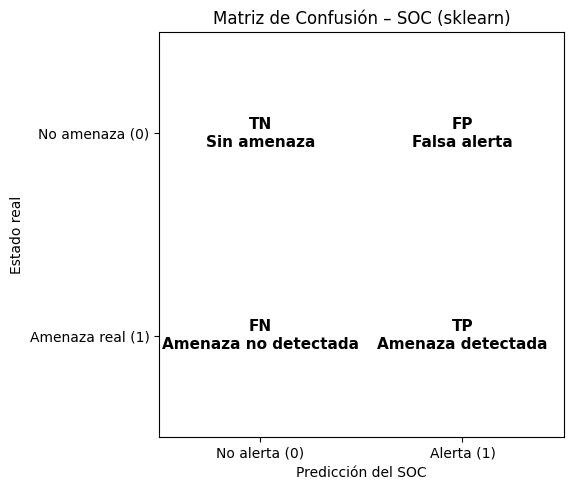

In [32]:
# Matriz SOLO para posicionar
matrix = np.zeros((2, 2))

labels = np.array([
    ["TN\nSin amenaza",        "FP\nFalsa alerta"],
    ["FN\nAmenaza no detectada","TP\nAmenaza detectada"]
])

plt.figure(figsize=(6, 5))
plt.imshow(matrix, cmap="Greys", alpha=0.2)

# Ejes según sklearn
plt.xticks([0, 1], ["No alerta (0)", "Alerta (1)"])
plt.yticks([0, 1], ["No amenaza (0)", "Amenaza real (1)"])

plt.xlabel("Predicción del SOC")
plt.ylabel("Estado real")
plt.title("Matriz de Confusión – SOC (sklearn)")

# Texto en cada celda
for i in range(2):
    for j in range(2):
        plt.text(j, i, labels[i, j],
                 ha="center", va="center",
                 fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [33]:
# Evaluamos el modelo en el conjunto de pruebay_prob = model.predict(X_test_proc).ravel()
y_prob = model.predict(X_test_proc).ravel()

prec, rec, th = precision_recall_curve(y_test, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-8)

best_idx = np.argmax(f1)
best_threshold = th[best_idx]

print("Best threshold (max F1):", best_threshold)

859/859 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step
Best threshold (max F1): 0.27119556


PR AUC: 0.9891352365246728

Classification report:

              precision    recall  f1-score   support

           0     0.6870    0.3210    0.4376      2523
           1     0.9349    0.9852    0.9594     24958

    accuracy                         0.9242     27481
   macro avg     0.8109    0.6531    0.6985     27481
weighted avg     0.9121    0.9242    0.9115     27481



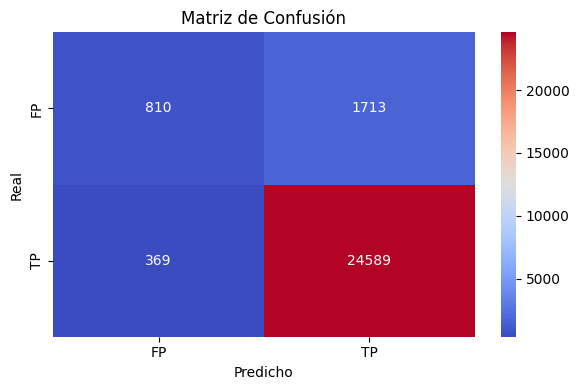

In [34]:
# Mostramos el informe de clasificación utilizando el umbral óptimo
y_pred = (y_prob >= best_threshold).astype(int)

print("PR AUC:", average_precision_score(y_test, y_prob))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))


# Vamos a visualizar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["FP", "TP"],
    yticklabels=["FP", "TP"]
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### 5 - Curvas de entrenamiento

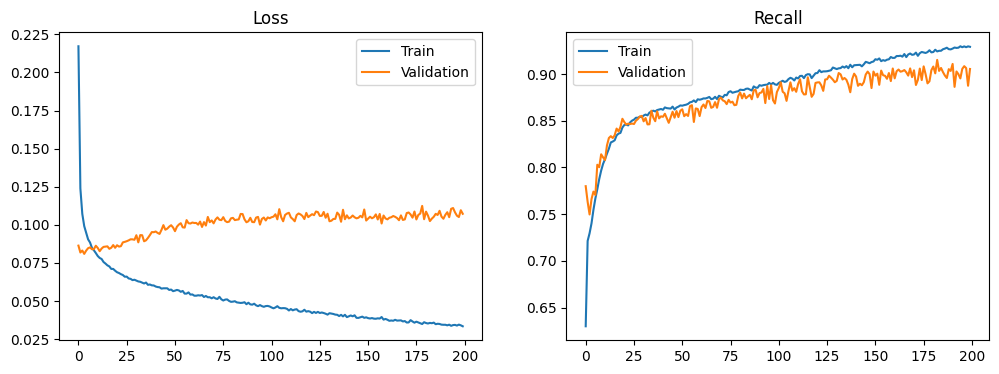

In [35]:
# Vamos a mostrar las curvas de entrenamiento y validación
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["recall"], label="Train")
plt.plot(history.history["val_recall"], label="Validation")
plt.title("Recall")
plt.legend()

plt.show()

### 6 - Curva PR

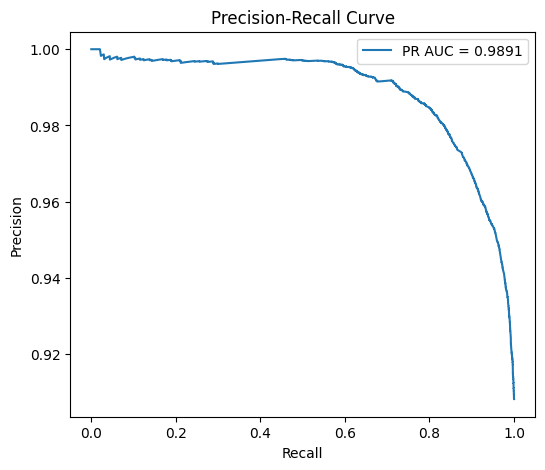

In [36]:
# Acabamos mostrando la curva ROC
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculamos el PR-AUC
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import f1_score

best_score = 0
best_threshold = 0

for t in np.linspace(0.01, 0.9, 300):
    y_pred_t = (y_prob >= t).astype(int)
    
    # F1 SOLO para clase 0
    score = f1_score(y_test, y_pred_t, pos_label=0)
    
    if score > best_score:
        best_score = score
        best_threshold = t

print("Best threshold (F1 clase 0):", best_threshold)
print("Best F1 clase 0:", best_score)

Best threshold (F1 clase 0): 0.3820735785953177
Best F1 clase 0: 0.5353233830845772


PR AUC: 0.9891352365246728

Classification report:

              precision    recall  f1-score   support

           0     0.5376    0.5331    0.5353      2523
           1     0.9528    0.9536    0.9532     24958

    accuracy                         0.9150     27481
   macro avg     0.7452    0.7434    0.7443     27481
weighted avg     0.9147    0.9150    0.9149     27481



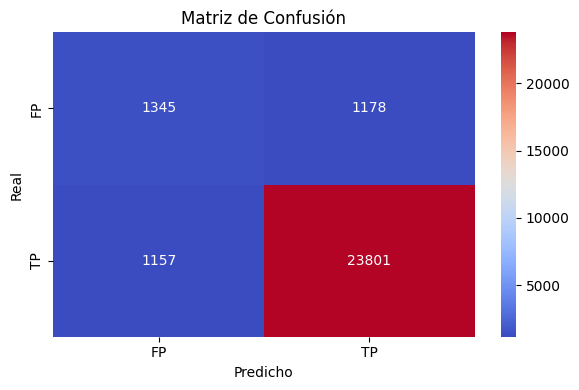

In [38]:
# Mostramos el informe de clasificación utilizando el umbral óptimo
y_pred = (y_prob >= best_threshold).astype(int)

print("PR AUC:", average_precision_score(y_test, y_prob))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))


# Vamos a visualizar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["FP", "TP"],
    yticklabels=["FP", "TP"]
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()